# Gradient Boosting Classifier

<h2>Definition</h2>

<p>
Gradient Boosting Classifier is an ensemble machine learning algorithm 
that builds a strong classification model by sequentially combining multiple weak learners 
(usually shallow decision trees).
</p>

<p>
Each new tree tries to reduce the errors made by the previous ensemble.
</p>

<hr>

<h2>Main Idea</h2>

<p>
Instead of training all trees independently, Gradient Boosting trains trees sequentially.
</p>

<p>
Each tree learns the residual errors or gradients of the previous model.
</p>

<pre>
Weak Learner 1
      ↓
Find Errors
      ↓
Weak Learner 2 Corrects Errors
      ↓
Weak Learner 3 Corrects Remaining Errors
      ↓
Strong Final Classifier
</pre>

<hr>

<h2>Why It Is Called Boosting</h2>

<p>
Each new weak learner improves or "boosts" the performance of the entire model.
</p>

<hr>

<h2>Why It Is Called Gradient</h2>

<p>
The algorithm minimizes the loss function using gradient descent optimization.
</p>

<p>
Trees are trained on negative gradients (pseudo residuals).
</p>

<hr>

<h2>Working of Gradient Boosting Classifier</h2>

<h3>Step 1: Initialize Prediction</h3>

<p>
The model starts with an initial prediction.
</p>

<p>
For binary classification:
</p>

<pre>
Initial prediction = log odds
</pre>

<hr>

<h3>Step 2: Compute Loss</h3>

<p>
The model calculates classification loss.
</p>

<p>
Common loss:
</p>

<pre>
Log Loss / Cross Entropy Loss
</pre>

<hr>

<h3>Step 3: Compute Residuals</h3>

<p>
Residuals are gradients of the loss function.
</p>

<pre>
Residual = Actual - Predicted Probability
</pre>

<hr>

<h3>Step 4: Train Weak Learner</h3>

<p>
A new decision tree is trained on residuals.
</p>

<hr>

<h3>Step 5: Update Prediction</h3>

<pre>
Fₘ(x) = Fₘ₋₁(x) + ηhₘ(x)
</pre>

<p>
Where:
</p>

<ul>
<li>Fₘ(x) → Updated prediction</li>
<li>η → Learning rate</li>
<li>hₘ(x) → New weak learner</li>
</ul>

<hr>

<h3>Step 6: Repeat</h3>

<p>
The process repeats until the model minimizes classification loss.
</p>

<hr>

<h2>Loss Function</h2>

<h3>Binary Classification</h3>

<pre>
Log Loss = -(y log(p) + (1-y) log(1-p))
</pre>

<hr>

<h3>Multiclass Classification</h3>

<pre>
LogLoss = -(1/N) Σ Σ yᵢⱼ log(pᵢⱼ)
</pre>

<p>
Where:
</p>

<ul>
<li>N → Number of samples</li>
<li>yᵢⱼ → Actual class indicator</li>
<li>pᵢⱼ → Predicted probability</li>
</ul>

<hr>

<h2>Learning Rate</h2>

<p>
Learning rate controls how much each tree contributes.
</p>

<pre>
Small Learning Rate → Slow but stable learning
Large Learning Rate → Faster but risk of overfitting
</pre>

<hr>

<h2>Important Hyperparameters</h2>

<table border="1" cellpadding="8">

<tr>
<th>Hyperparameter</th>
<th>Purpose</th>
</tr>

<tr>
<td>n_estimators</td>
<td>Number of trees</td>
</tr>

<tr>
<td>learning_rate</td>
<td>Controls correction size</td>
</tr>

<tr>
<td>max_depth</td>
<td>Depth of each tree</td>
</tr>

<tr>
<td>subsample</td>
<td>Fraction of samples used per tree</td>
</tr>

<tr>
<td>max_features</td>
<td>Features considered for split</td>
</tr>

</table>

<hr>

<h2>Advantages</h2>

<ul>
<li>High prediction accuracy</li>
<li>Handles nonlinear relationships well</li>
<li>Works for binary and multiclass classification</li>
<li>Reduces bias effectively</li>
<li>Captures complex patterns</li>
</ul>

<hr>

<h2>Disadvantages</h2>

<ul>
<li>Training can be slow</li>
<li>Sensitive to hyperparameters</li>
<li>Can overfit if too many trees are used</li>
<li>Harder to interpret than single decision trees</li>
</ul>

<hr>

<h2>Difference Between AdaBoost and Gradient Boosting</h2>

<table border="1" cellpadding="8">

<tr>
<th>AdaBoost</th>
<th>Gradient Boosting</th>
</tr>

<tr>
<td>Focuses on misclassified datapoints</td>
<td>Focuses on residual errors</td>
</tr>

<tr>
<td>Uses sample weights</td>
<td>Uses gradients/loss minimization</td>
</tr>

<tr>
<td>Sequential weighted learning</td>
<td>Sequential residual correction</td>
</tr>

<tr>
<td>Simpler algorithm</td>
<td>More optimization-based</td>
</tr>

</table>

<hr>

<h2>Feature Importance</h2>

<p>
Gradient Boosting can calculate feature importance scores.
</p>

<p>
Important features contribute more to predictions.
</p>

<hr>

<h2>Popular Implementations</h2>

<ul>
<li>GradientBoostingClassifier</li>
<li>XGBoost</li>
<li>LightGBM</li>
<li>CatBoost</li>
</ul>

<hr>

<h2>Applications</h2>

<ul>
<li>Fraud detection</li>
<li>Spam classification</li>
<li>Customer churn prediction</li>
<li>Medical diagnosis</li>
<li>Recommendation systems</li>
</ul>

<hr>

<h2>One-Line Summary</h2>

<p>
Gradient Boosting Classifier builds a strong classifier by sequentially training weak learners 
to minimize classification loss using gradient descent optimization.
</p>


In [5]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("heart.csv")
X=df.iloc[:,0:-1]
y=df.iloc[:,-1]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [8]:
model=GradientBoostingClassifier()
param_grid={
    'learning_rate':[0.1,0.2,0.3],
    'n_estimators':[100,200,400,500],
    'subsample':[0.2,0.5,0.7,0.8],
    'max_depth':[3,5,7]
}

In [9]:
gc=GridSearchCV(estimator=model,param_grid=param_grid,cv=5,verbose=2,n_jobs=-1)
gc.fit(X_train,y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.2, 0.3],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 400, 500],
                         'subsample': [0.2, 0.5, 0.7, 0.8]},
             verbose=2)

In [10]:
best_model=gc.best_estimator_
pred=best_model.predict(X_test)
accuracy_score(pred,y_test)

0.9853658536585366

In [18]:
best_model.predict([[67,1,0,160,286,0,0,108,1,1.5,1,3,2]])

c:\Users\mysel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

c:\Users\mysel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


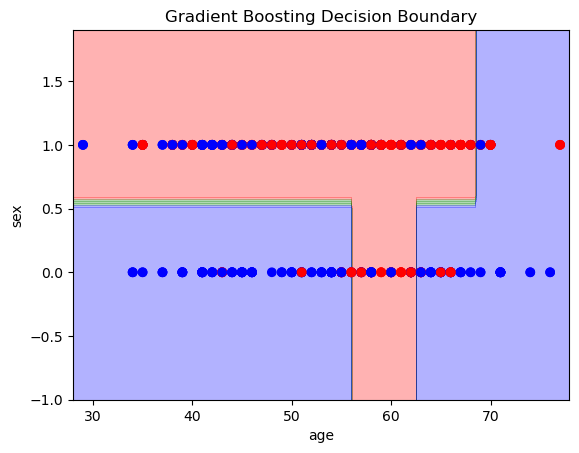

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X = X_train.values
y = y_train.values

# Select 2 features for visualization
f1 = 0
f2 = 1

# Meshgrid
x1_min, x1_max = X[:, f1].min()-1, X[:, f1].max()+1
x2_min, x2_max = X[:, f2].min()-1, X[:, f2].max()+1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 0.1),
    np.arange(x2_min, x2_max, 0.1)
)

# Create full feature input
grid = np.zeros((xx1.ravel().shape[0], X.shape[1]))

# Fill all features with mean values
grid[:] = X.mean(axis=0)

# Replace selected features
grid[:, f1] = xx1.ravel()
grid[:, f2] = xx2.ravel()

# Prediction using trained model
Z = best_model.predict(grid)

Z = Z.reshape(xx1.shape)

# Plot boundary
plt.contourf(
    xx1,
    xx2,
    Z,
    alpha=0.3,
    cmap=ListedColormap(('red','green','blue'))
)

# Actual points
plt.scatter(
    X[:, f1],
    X[:, f2],
    c=y,
    cmap=ListedColormap(('red','green','blue'))
)

plt.xlabel(X_train.columns[f1])
plt.ylabel(X_train.columns[f2])
plt.title("Gradient Boosting Decision Boundary")

plt.show()